# Titanic Survival Prediction (Python + CUDA GPU)
Using RAPIDS (cuDF + cuML)

## 1️⃣ Imports

In [1]:
!pip install cudf-cu12 cuml-cu12 cupy-cuda12x
!pip install pandas seaborn matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 15.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82


In [2]:
import cudf
import cupy as cp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from cuml.model_selection import train_test_split
from cuml.ensemble import RandomForestClassifier
from cuml.svm import SVC

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, accuracy_score
)

## 2️⃣ Load Dataset (GPU)

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = cudf.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,<NA>,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,<NA>,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,<NA>,S


## 3️⃣ EDA (Visualization)

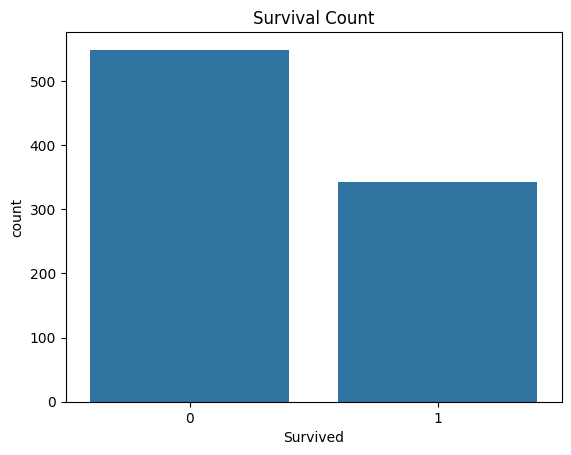

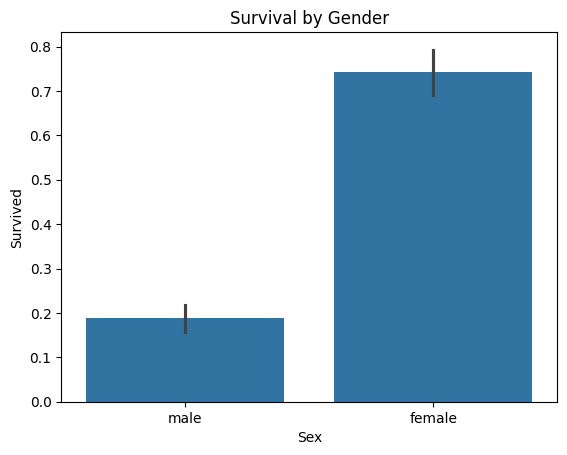

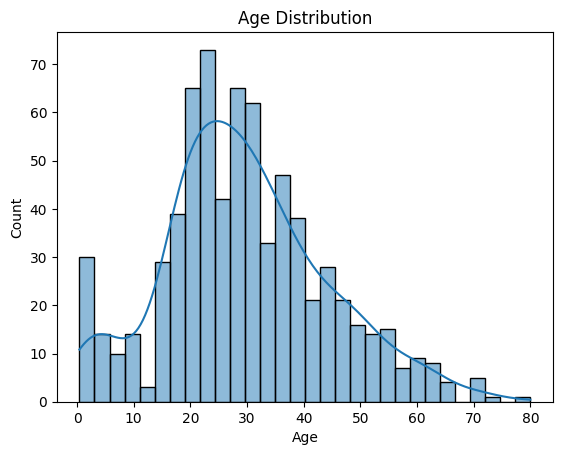

In [4]:
pdf = df.to_pandas()

sns.countplot(x='Survived', data=pdf)
plt.title("Survival Count")
plt.show()

sns.barplot(x='Sex', y='Survived', data=pdf)
plt.title("Survival by Gender")
plt.show()

sns.histplot(pdf['Age'].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

## 4️⃣ Preprocessing (GPU)

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(columns=['Cabin'])

df['Sex'] = df['Sex'].astype('category').cat.codes
df['Embarked'] = df['Embarked'].astype('category').cat.codes

df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])

## 5️⃣ Train-Test Split

In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 6️⃣ Train Models (GPU)

In [9]:
rf = RandomForestClassifier(max_depth=5, n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test).to_pandas().iloc[:, 1]

svc = SVC()
svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)

## 7️⃣ Convert to CPU

In [13]:
y_test_cpu = y_test.to_pandas()

y_pred_rf_cpu = y_pred_rf.to_pandas()
y_pred_svc_cpu = y_pred_svc.to_pandas()

y_prob_rf_cpu = y_prob_rf

## 8️⃣ Accuracy

In [15]:
print("RF Accuracy:", accuracy_score(y_test_cpu, y_pred_rf_cpu))
print("SVC Accuracy:", accuracy_score(y_test_cpu, y_pred_svc_cpu))

RF Accuracy: 0.8156424581005587
SVC Accuracy: 0.659217877094972


## 9️⃣ Confusion Matrix

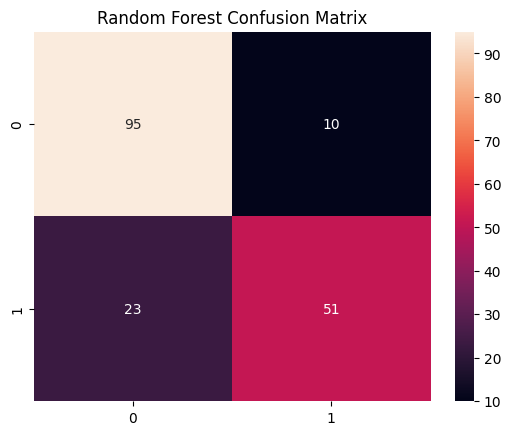

In [16]:
cm = confusion_matrix(y_test_cpu, y_pred_rf_cpu)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

## 🔟 Classification Report

In [18]:
print("Random Forest Report:\n")
print(classification_report(y_test_cpu, y_pred_rf_cpu))

print("SVC Report:\n")
print(classification_report(y_test_cpu, y_pred_svc_cpu))

Random Forest Report:

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179

SVC Report:

              precision    recall  f1-score   support

           0       0.64      0.94      0.76       105
           1       0.76      0.26      0.38        74

    accuracy                           0.66       179
   macro avg       0.70      0.60      0.57       179
weighted avg       0.69      0.66      0.61       179



## 1️⃣1️⃣ ROC Curve

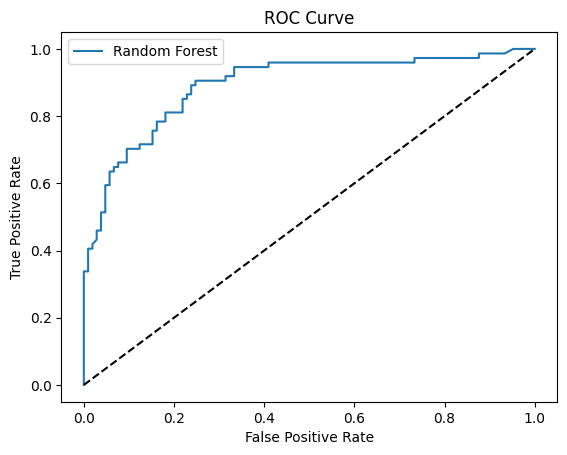

In [19]:
fpr_rf, tpr_rf, _ = roc_curve(y_test_cpu, y_prob_rf_cpu)

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 1️⃣2️⃣ ROC-AUC Score

In [21]:
print("RF AUC:", roc_auc_score(y_test_cpu, y_prob_rf_cpu))

RF AUC: 0.8918275418275418
